In [29]:
# Publication-friendly plotting setup (Matplotlib + Seaborn)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


# ---- Theme ----
def set_pub_theme(font_size=9, line_width=0.5, font_scale=0.75):
    _new_black = '#373737'  # "never use pure black"
    sns.set_theme(style='ticks', font_scale=font_scale, rc={
        # Fonts/output
        'font.family': 'serif',
        'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'],
        'svg.fonttype': 'none',     # keep text as text in SVG
        'text.usetex': False,
        'pdf.fonttype': 42,         # editable text in Adobe apps
        'ps.fonttype': 42,

        # Sizes
        'font.size': font_size,
        'axes.labelsize': font_size,
        'axes.titlesize': font_size,
        'legend.fontsize': font_size,
        'legend.title_fontsize': font_size,
        'xtick.labelsize': font_size,
        'ytick.labelsize': font_size,
        'axes.labelpad': 2,
        'axes.titlepad': 4,

        # Line widths
        'axes.linewidth': line_width,
        'lines.linewidth': line_width,
        'xtick.major.width': line_width,
        'ytick.major.width': line_width,
        'xtick.minor.width': line_width,
        'ytick.minor.width': line_width,
        'xtick.major.size': 2, 'ytick.major.size': 2,
        'xtick.minor.size': 2, 'ytick.minor.size': 2,
        'xtick.major.pad': 1, 'ytick.major.pad': 1,
        'xtick.minor.pad': 1, 'ytick.minor.pad': 1,

        # Neutral—not black
        'text.color': _new_black,
        'axes.edgecolor': _new_black,
        'axes.labelcolor': _new_black,
        'xtick.color': _new_black,
        'ytick.color': _new_black,
        'patch.edgecolor': _new_black,
        'patch.force_edgecolor': False,  # cleaner hist bars
        'hatch.color': _new_black,
    })

# ---- Color palettes (Paul Tol qualitative sets) ----
def tol_palette(name='bright'):
    sets = {
        'bright': ['#4477AA','#EE6677','#228833','#CCBB44','#66CCEE','#AA3377','#BBBBBB','#000000'],
        'high-contrast': ['#004488','#DDAA33','#BB5566','#000000'],
        'vibrant': ['#EE7733','#0077BB','#33BBEE','#EE3377','#CC3311','#009988','#BBBBBB','#000000'],
        'muted': ['#CC6677','#332288','#DDCC77','#117733','#88CCEE','#882255','#44AA99','#999933','#AA4499','#DDDDDD','#000000'],
    }
    return sets.get(name, sets['bright'])

# ---- Helpful utilities ----
def panel(figsize=(3,2), dpi=150):
    """Create an axes at print-ready size (inches)."""
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    return fig, ax

def raster_scatter(ax, x, y, c=None, s=1.0, cmap=mpl.cm.viridis, **kwargs):
    """Fast, vector-friendly scatter: rasterize only the points."""
    return ax.scatter(x, y, s=s, c=c, cmap=cmap, edgecolor='none', rasterized=True, **kwargs)

def side_colorbar(fig, mappable, label=''):
    """Right-side colorbar with top label (avoids rotated text)."""
    gs_cbar = fig.add_gridspec(1, 1, left=0.92, right=0.95)
    cax = fig.add_subplot(gs_cbar[0, 0])
    fig.colorbar(mappable, cax=cax)
    cax.text(1, 1.01, label, transform=cax.transAxes, ha='right', va='bottom')

def annotate_ax(ax, txt, x=0.05, y=0.95, **kw):
    """Axis-relative text placement (stable across data ranges)."""
    ax.text(x, y, txt, transform=ax.transAxes, ha='left', va='top', **kw)


In [20]:
df = pd.read_csv('./../analysis/results_continuous/benchmark_results_all.csv')
# Create a mapping dictionary for algorithm names
algorithm_mapping = {
    'directlingam_pd2': 'DirectLiNGAM',
    'grasp_tetrad_pd2': 'GRASP',
    'fges_tetrad_pd2': 'FGES', 
    'boss_tetrad_pd2': 'BOSS',
    'pc_tetrad_05': 'PC',
    'dagma_tetrad_pd2': 'DAGMA'
}

# Replace algorithm names in the dataframe
df['algorithm_name'] = df['algorithm_name'].map(algorithm_mapping)


In [39]:
df.columns

Index(['timestamp', 'dataset_name', 'algorithm_name', 'nodes', 'npoints',
       'expected_degree', 'true_num_edges', 'mechanism', 'training_time',
       'skeleton_shd', 'skeleton_precision', 'skeleton_recall', 'skeleton_f1',
       'shd', 'precision', 'recall', 'f1', 'normalized_skeleton_shd',
       'possible_edges_normalized_shd', 'true_support_normalized_shd',
       'est_support_normalized_shd', 'average_frequency', 'median_frequency',
       'min_frequency', 'average_edge_frequency', 'brier', 'ece'],
      dtype='object')

In [34]:
df['mechanism'].unique()
# Create a mapping dictionary for mechanism names
mechanism_mapping = {
    'sigmoid_add-binary': 'Sigmoid+Binary',
    'nn': 'NN',
    'nn-binary': 'NN+Binary', 
    'linear': 'Linear',
    'polynomial': 'Polynomial',
    'polynomial-binary': 'Polynomial+Binary',
    'linear-binary': 'Linear+Binary',
    'sigmoid_add': 'Sigmoid',
    'binary': 'Binary'
}

# Replace mechanism names in the dataframe
df['mechanism'] = df['mechanism'].map(mechanism_mapping)


In [21]:
metrics = [
       # 'skeleton_shd',
       'skeleton_precision',
       'skeleton_recall',
       'skeleton_f1',
       # 'shd',
       'precision',
       'recall',
       'f1',
       # 'normalized_skeleton_shd',
       # 'possible_edges_normalized_shd',
       'median_frequency',
       'brier',
       'ece'
]

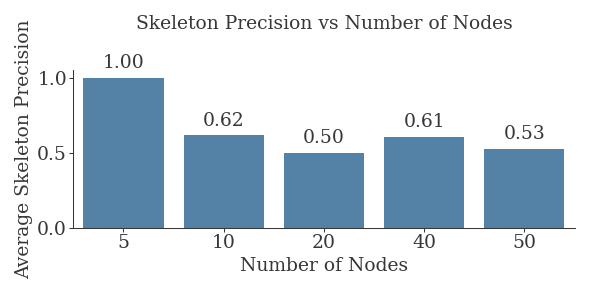

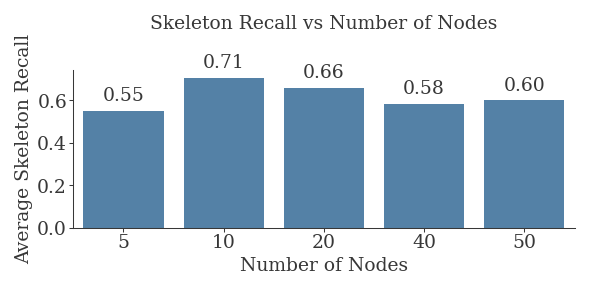

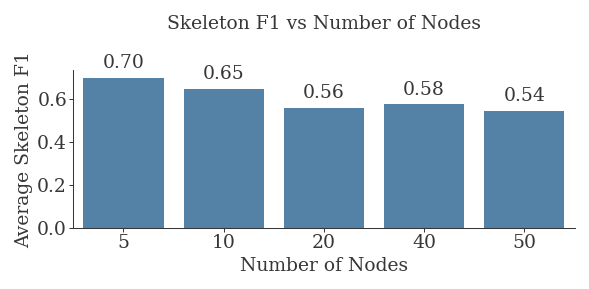

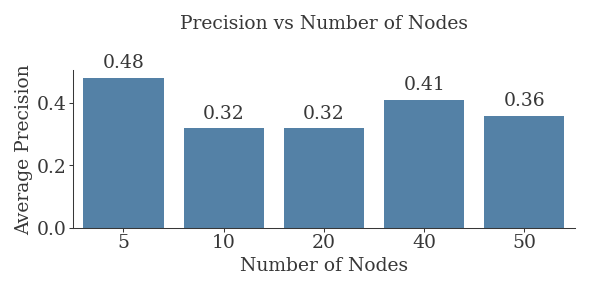

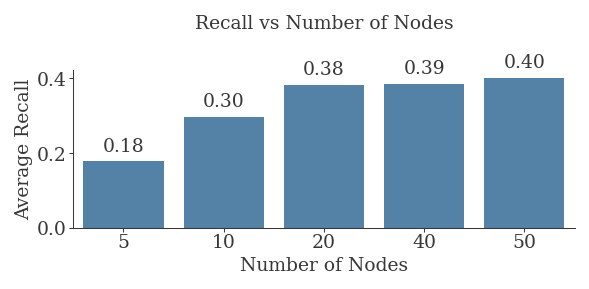

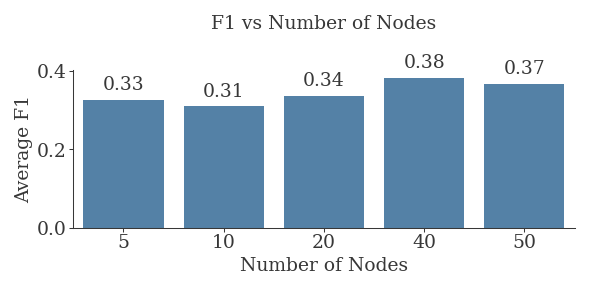

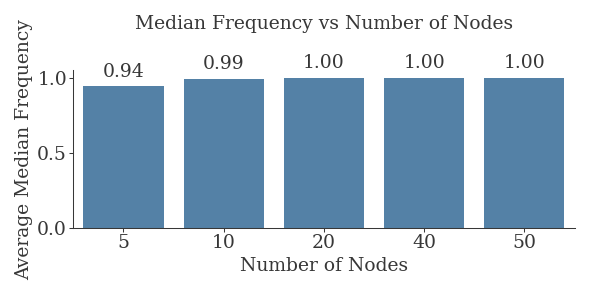

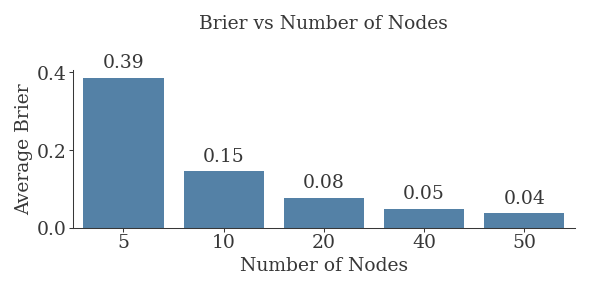

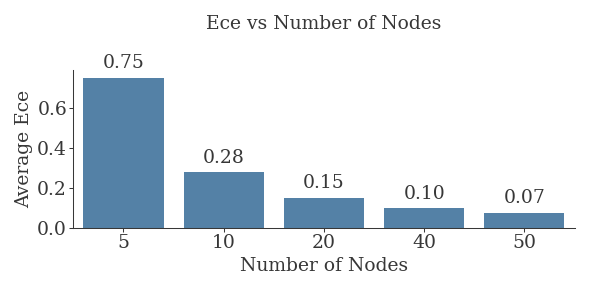

In [41]:
def plot_metric_by_nodes_overall(df, metric, fpath=None):
    """
    Plot a bar chart showing the average of the given metric vs number of nodes.
    
    Args:
        df: pandas DataFrame containing the data
        metric: str, name of metric column to plot
        fpath: str, optional filepath to save the plot
    """
    # Set publication theme
    set_pub_theme()

    Path(fpath).parent.mkdir(parents=True, exist_ok=True)
    # Calculate mean metric by number of nodes
    mean_by_nodes = df.groupby('nodes')[metric].mean().reset_index()

    # Create figure and axis 
    fig, ax = plt.subplots(figsize=(4, 2), dpi=150)

    # Create bar plot
    bars = sns.barplot(data=mean_by_nodes, x='nodes', y=metric,
                color='steelblue', errorbar=None)
    
    # Add value labels on top of bars
    for i in bars.containers:
        bars.bar_label(i, fmt='%.2f', padding=3)

    # Customize axis
    ax.set_xlabel('Number of Nodes')
    ax.set_ylabel(f'Average {metric.replace("_", " ").title()}')
    ax.set_title(f'{metric.replace("_", " ").title()} vs Number of Nodes', pad=20)

    # Remove spines and adjust layout
    sns.despine()
    plt.tight_layout()
    
    if fpath:
        plt.savefig(fpath, bbox_inches='tight', dpi=150)
    
    plt.show()

for metric in metrics:
    plot_metric_by_nodes_overall(df, metric, f'./plots/by_nodes_overall/{metric}.png')

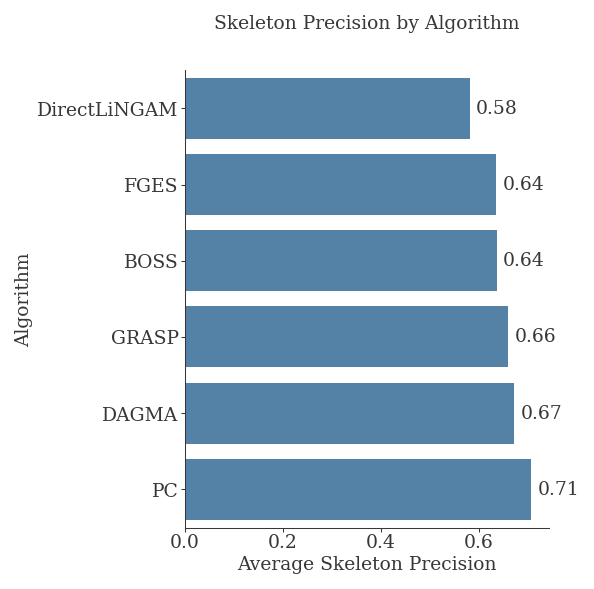

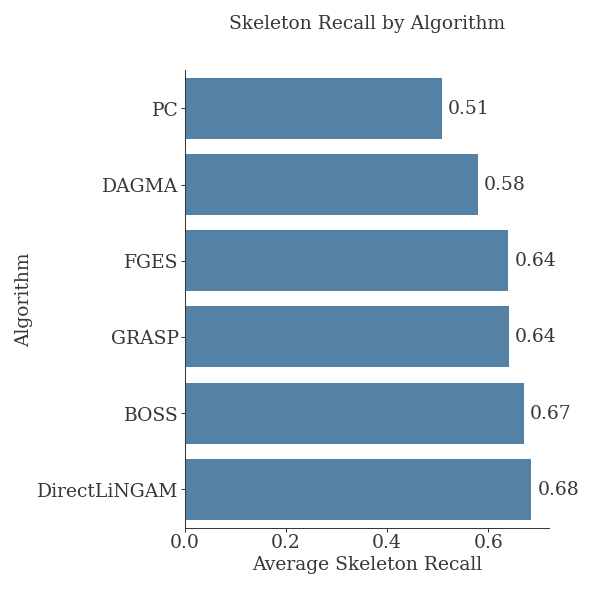

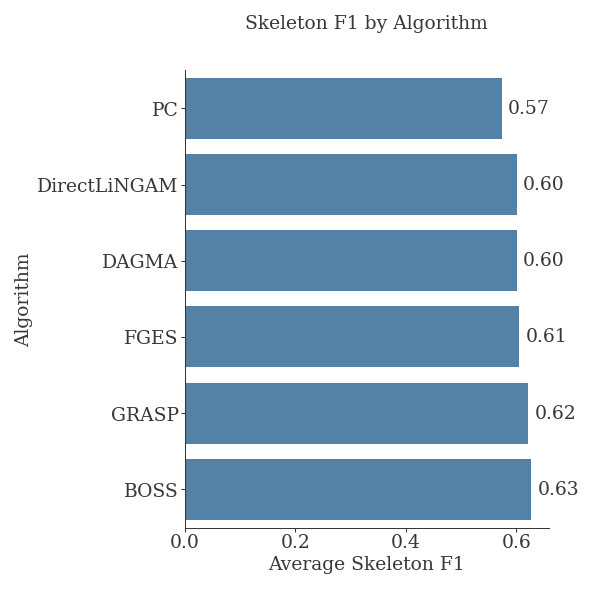

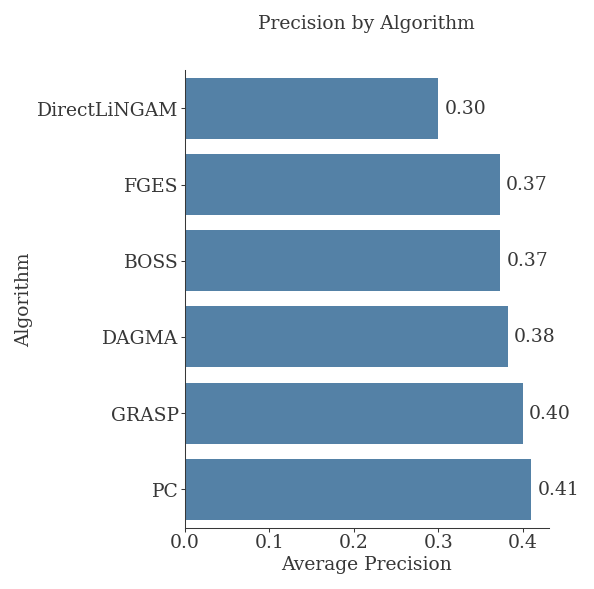

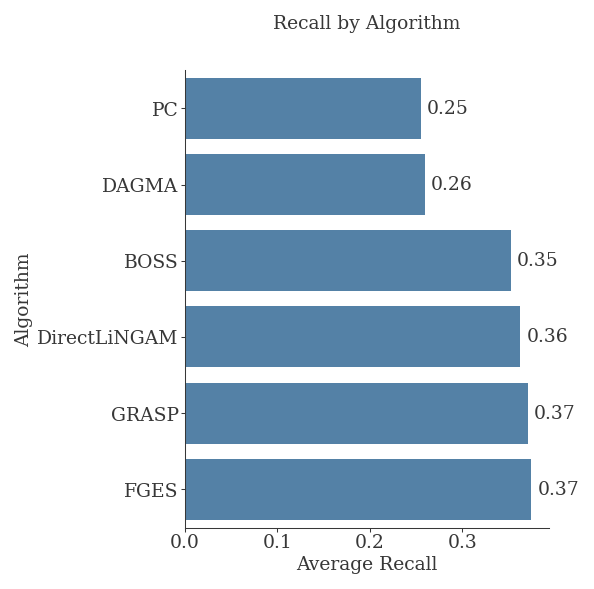

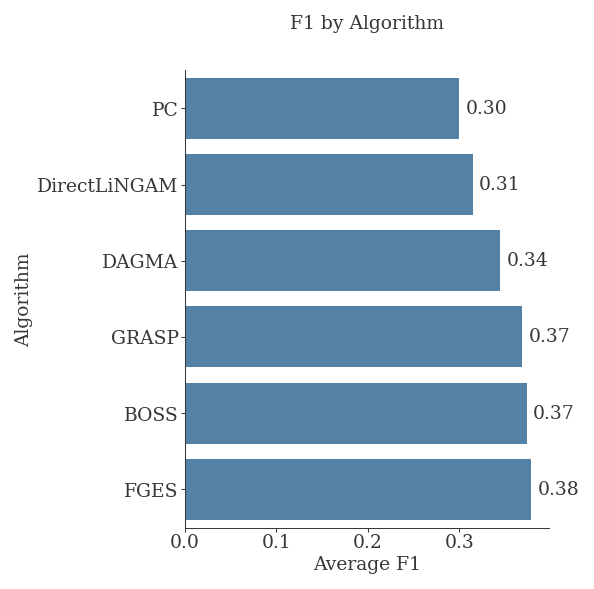

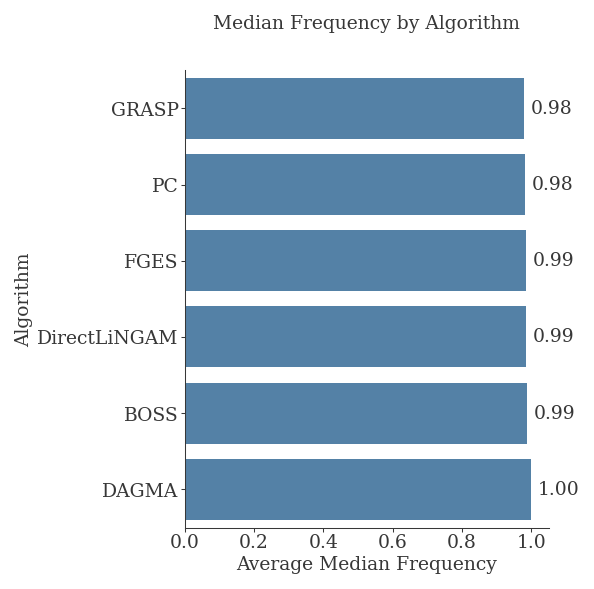

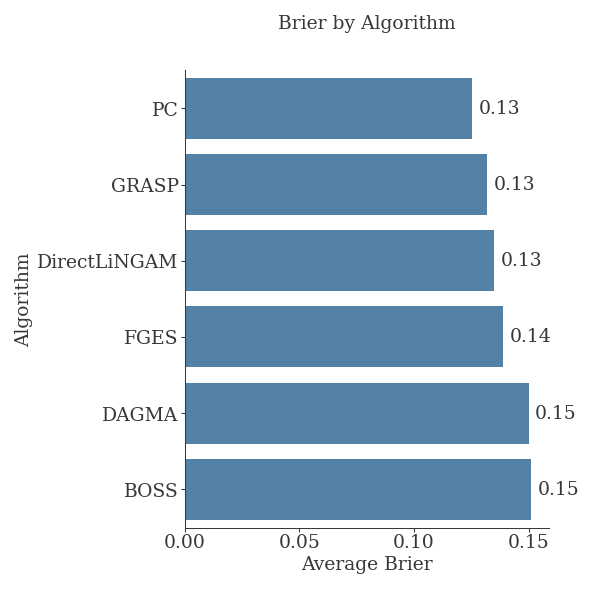

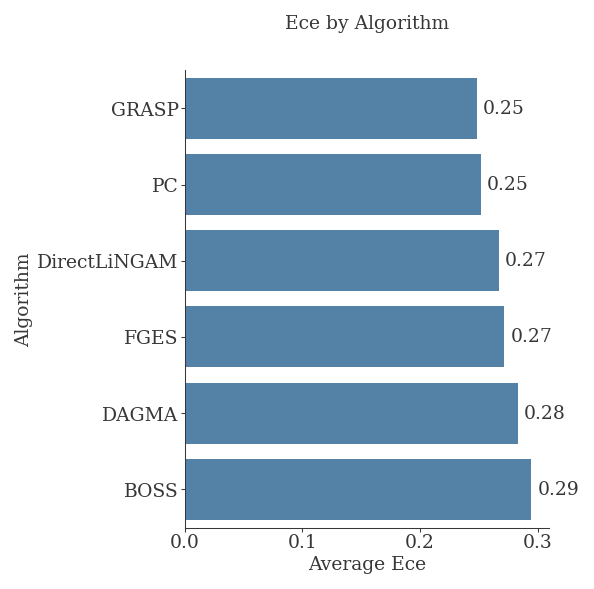

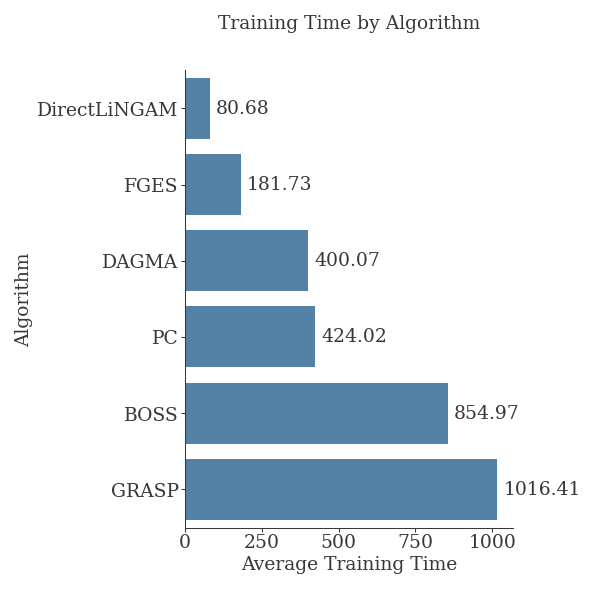

In [40]:
def plot_metric_by_algorithm(df, metric, fpath=None):
    """
    Plot a horizontal bar chart showing the average of the given metric for each algorithm.
    
    Args:
        df: pandas DataFrame containing the data
        metric: str, name of metric column to plot
        fpath: str, optional filepath to save the plot
    """
    # Set publication theme
    set_pub_theme()

    if fpath:
        Path(fpath).parent.mkdir(parents=True, exist_ok=True)
        
    # Calculate mean metric by algorithm
    mean_by_algorithm = df.groupby('algorithm_name')[metric].mean().sort_values()

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(4, 4), dpi=150)

    # Create horizontal bar plot
    bars = sns.barplot(x=mean_by_algorithm.values, y=mean_by_algorithm.index,
                      color='steelblue', orient='h', errorbar=None)
    
    # Add value labels at end of bars
    for i in bars.containers:
        bars.bar_label(i, fmt='%.2f', padding=3)

    # Customize axis
    ax.set_xlabel(f'Average {metric.replace("_", " ").title()}')
    ax.set_ylabel('Algorithm')
    ax.set_title(f'{metric.replace("_", " ").title()} by Algorithm', pad=20)

    # Add grid

    # Remove spines and adjust layout
    sns.despine()
    plt.tight_layout()
    
    if fpath:
        plt.savefig(fpath, bbox_inches='tight', dpi=150)
        
    plt.show()

for metric in metrics + ['training_time']:
    plot_metric_by_algorithm(df, metric, f'./plots/by_algorithm/{metric}.png')


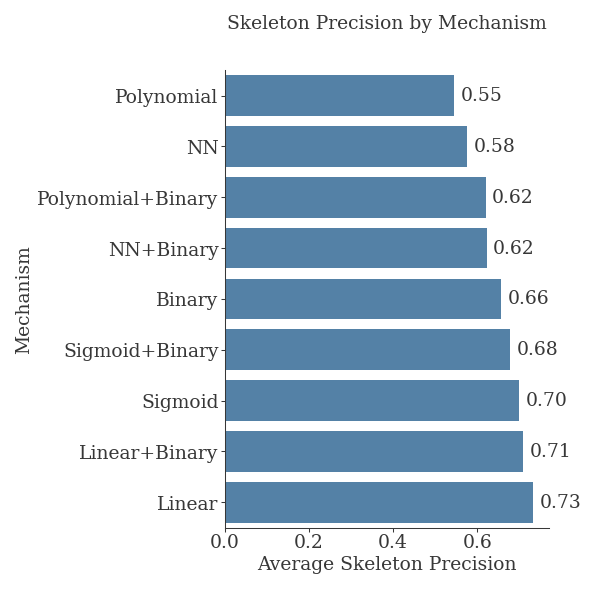

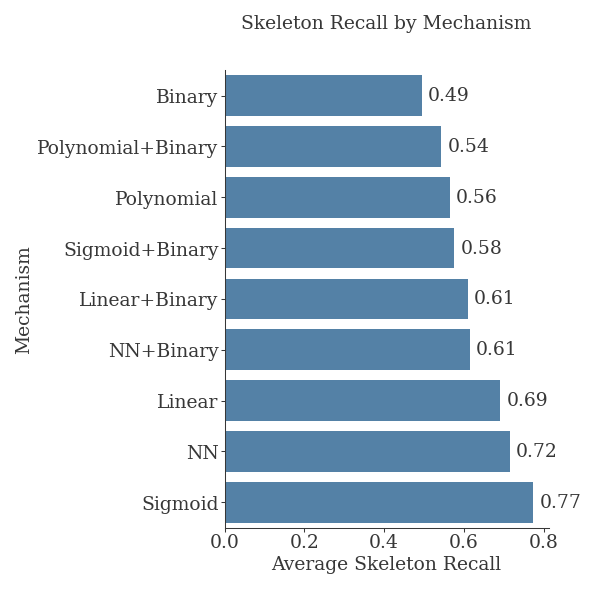

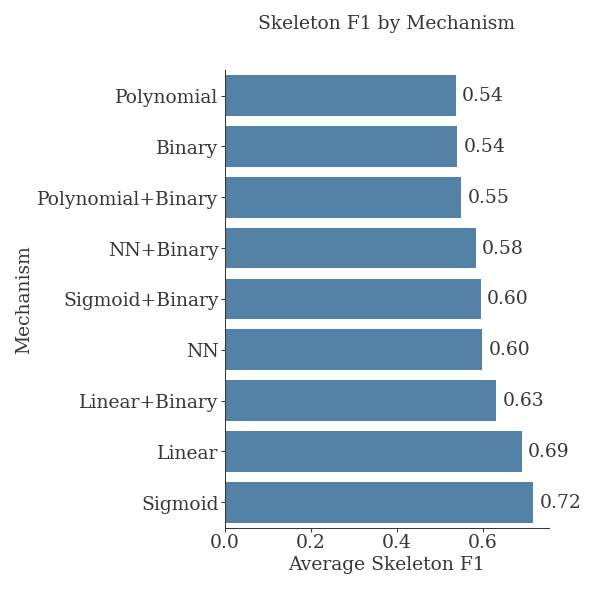

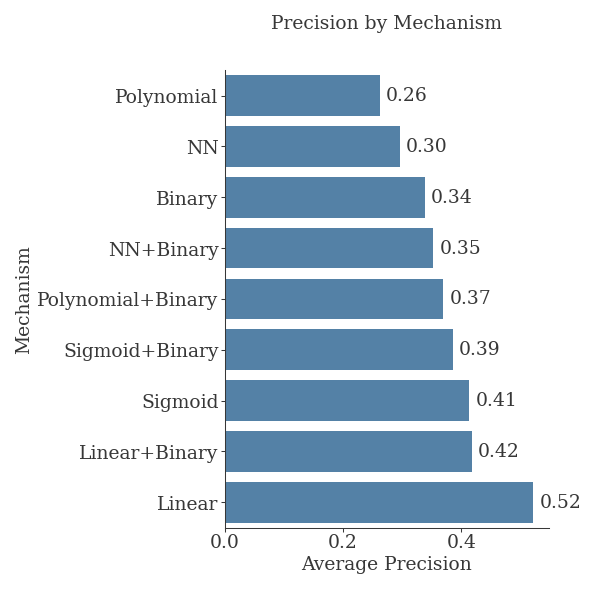

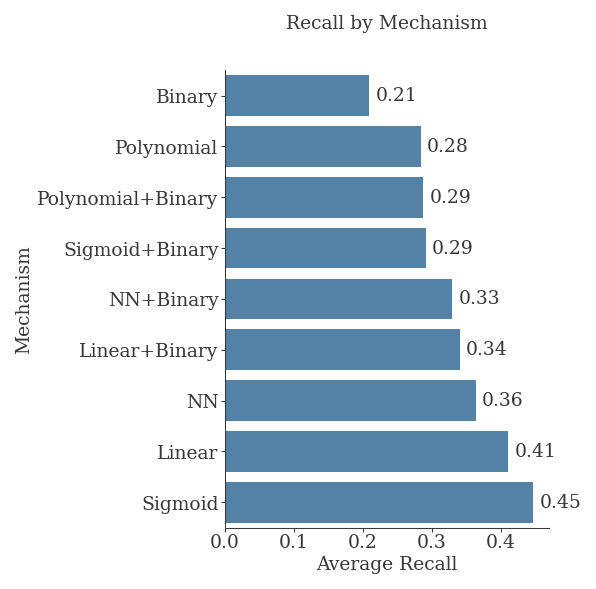

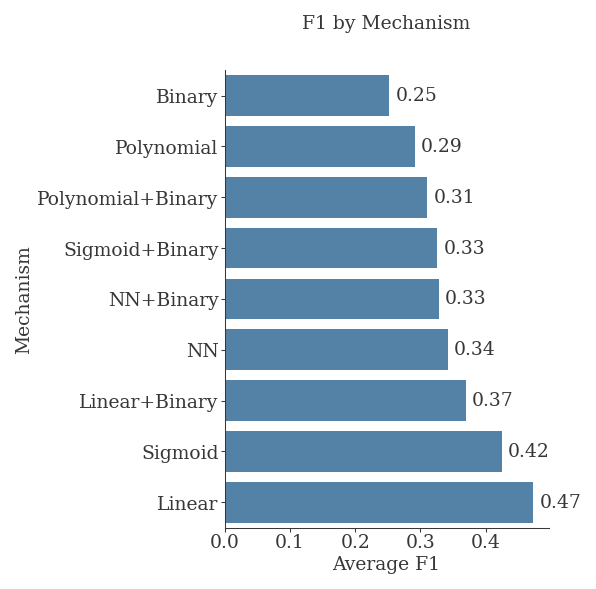

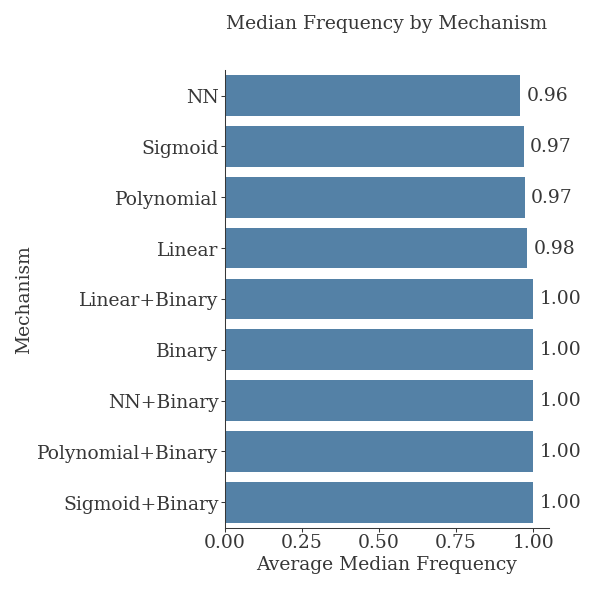

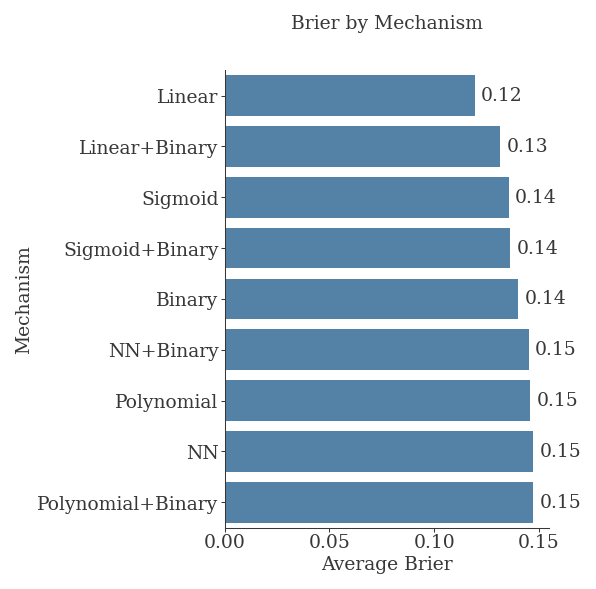

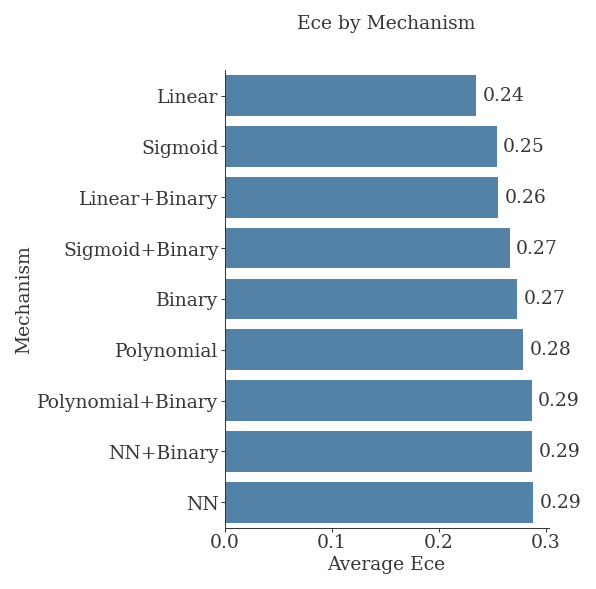

In [35]:
def plot_metric_by_mechanism(df, metric, fpath=None):
    """
    Plot a horizontal bar chart showing the average of the given metric for each mechanism.
    
    Args:
        df: pandas DataFrame containing the data
        metric: str, name of metric column to plot
        fpath: str, optional filepath to save the plot
    """
    # Set publication theme
    set_pub_theme()

    if fpath:
        Path(fpath).parent.mkdir(parents=True, exist_ok=True)
        
    # Calculate mean metric by mechanism
    mean_by_mechanism = df.groupby('mechanism')[metric].mean().sort_values()

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(4, 4), dpi=150)

    # Create horizontal bar plot
    bars = sns.barplot(x=mean_by_mechanism.values, y=mean_by_mechanism.index,
                      color='steelblue', orient='h', errorbar=None)
    
    # Add value labels at end of bars
    for i in bars.containers:
        bars.bar_label(i, fmt='%.2f', padding=3)

    # Customize axis
    ax.set_xlabel(f'Average {metric.replace("_", " ").title()}')
    ax.set_ylabel('Mechanism')
    ax.set_title(f'{metric.replace("_", " ").title()} by Mechanism', pad=20)

    # Add grid

    # Remove spines and adjust layout
    sns.despine()
    plt.tight_layout()
    
    if fpath:
        plt.savefig(fpath, bbox_inches='tight', dpi=150)
        
    plt.show()

for metric in metrics:
    plot_metric_by_mechanism(df, metric, f'./plots/by_mechanism/{metric}.png')


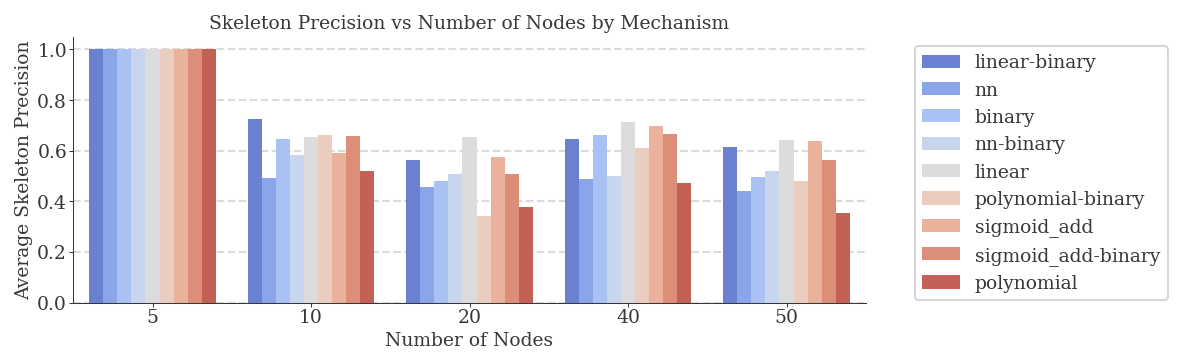

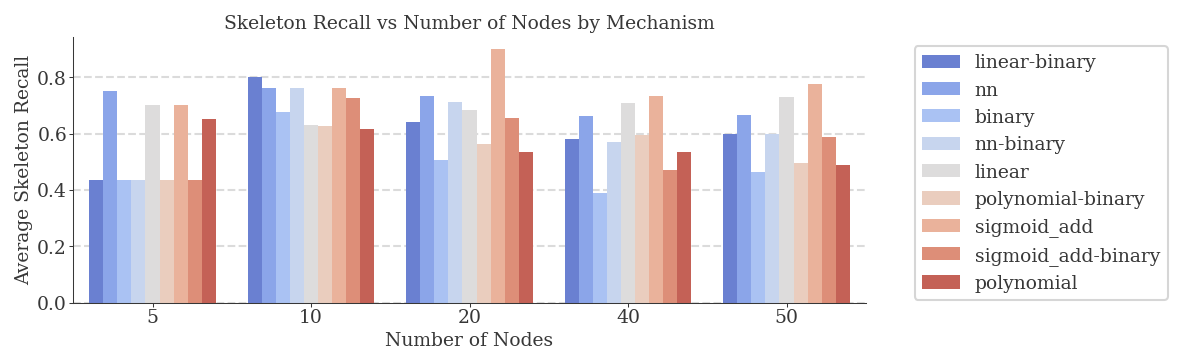

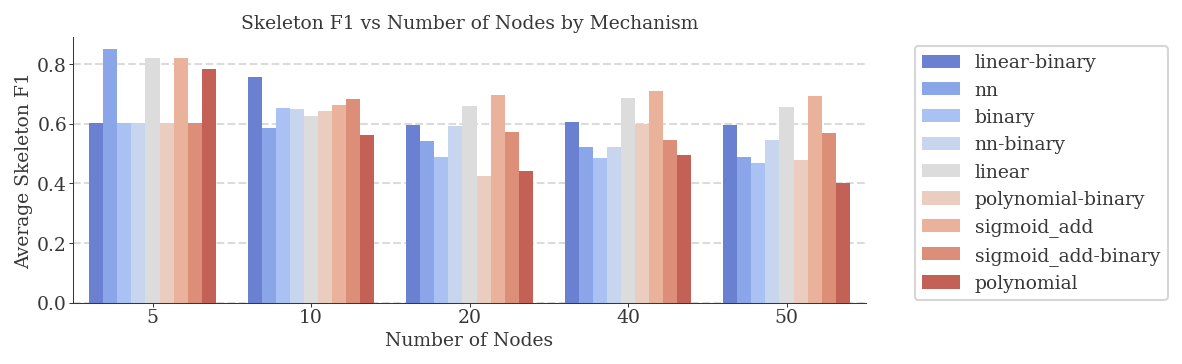

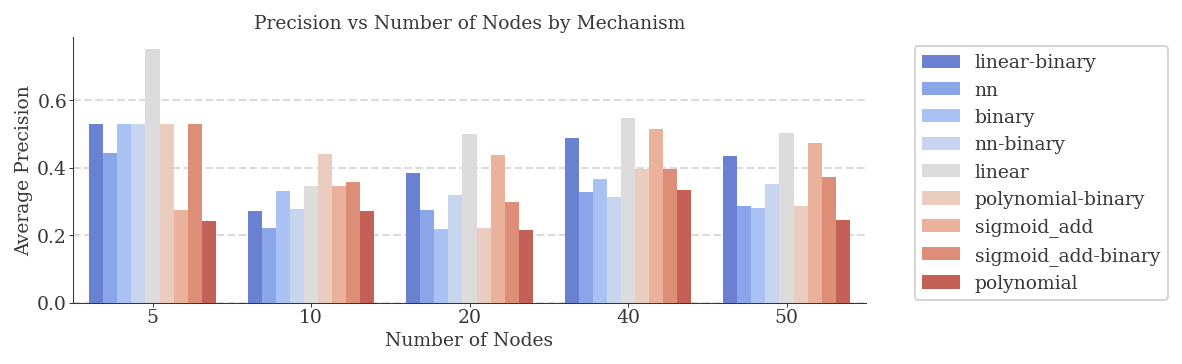

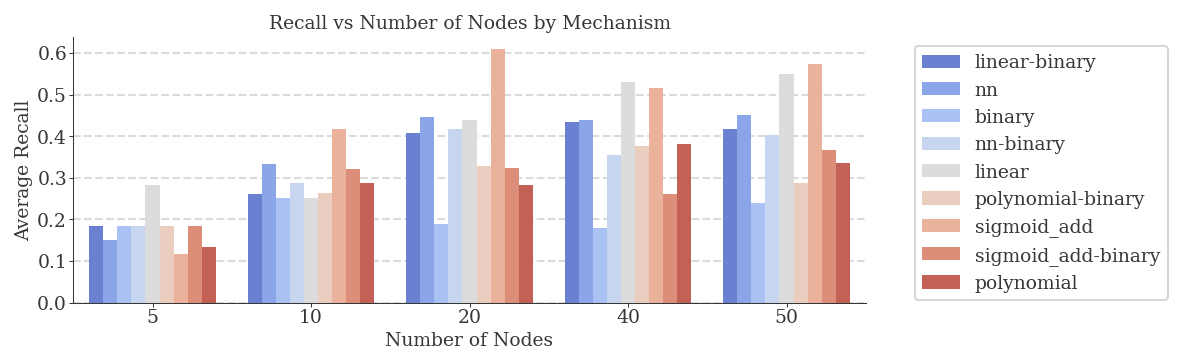

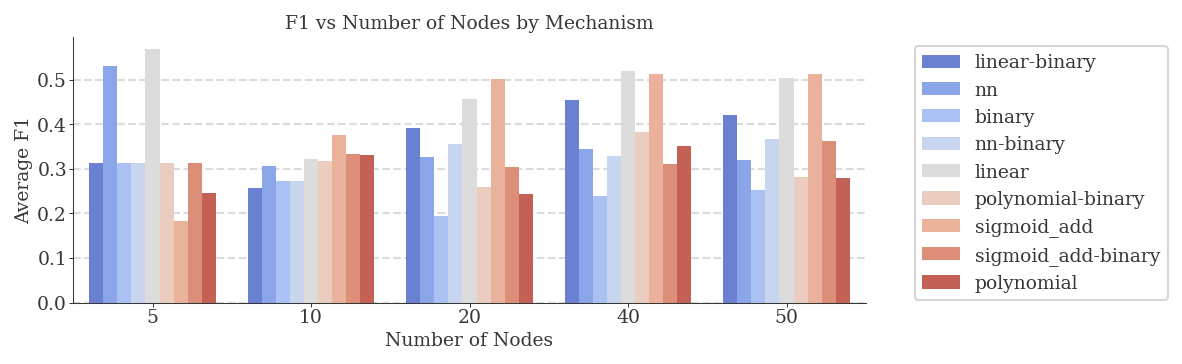

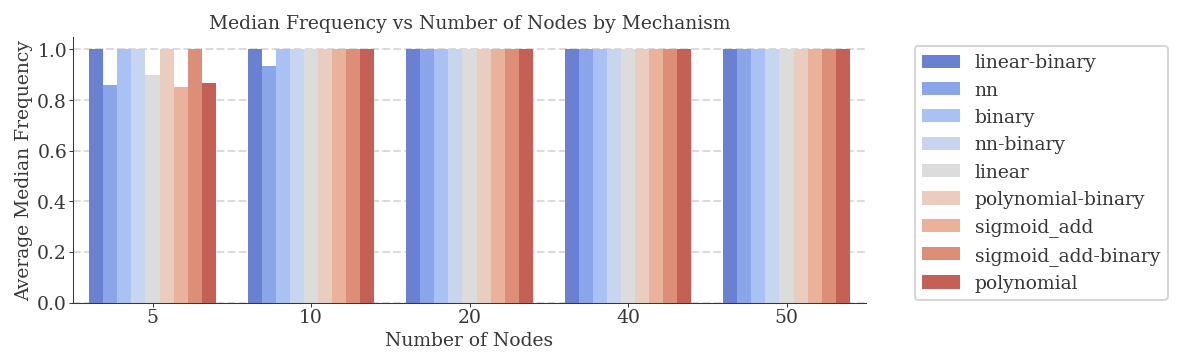

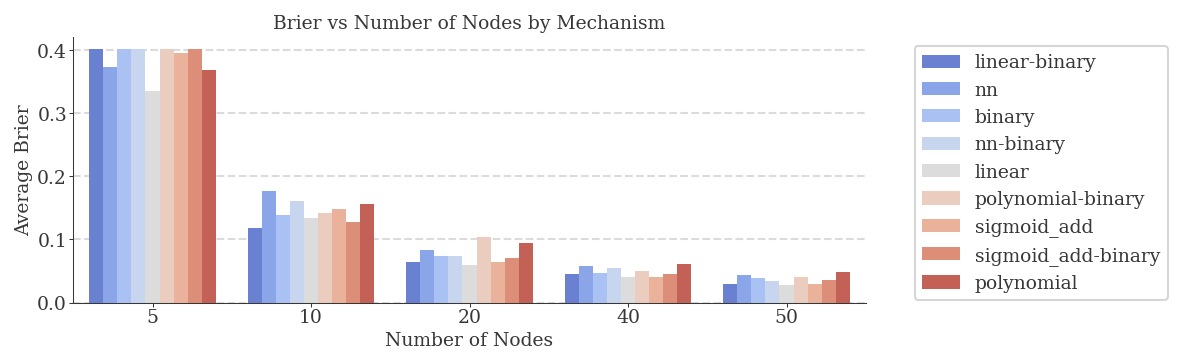

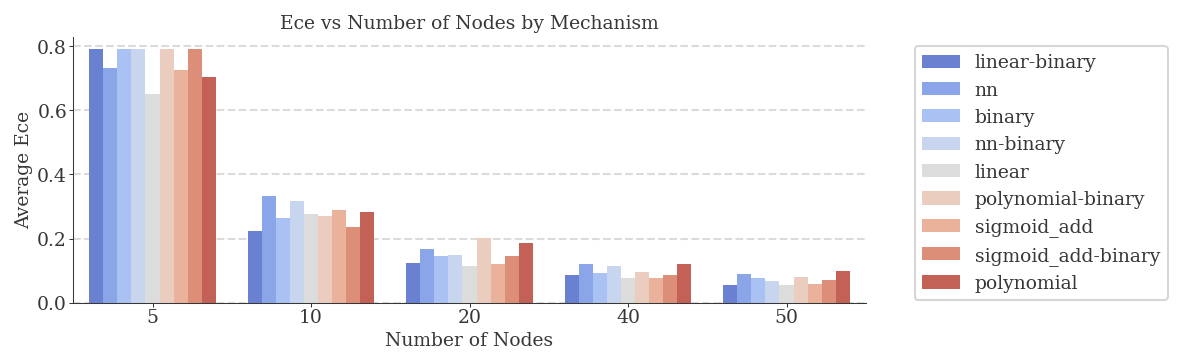

In [25]:
for metric in metrics:
    plot_metric_by_nodes(df, metric, f'./plots/by_nodes_and_mechanism/{metric}.png')

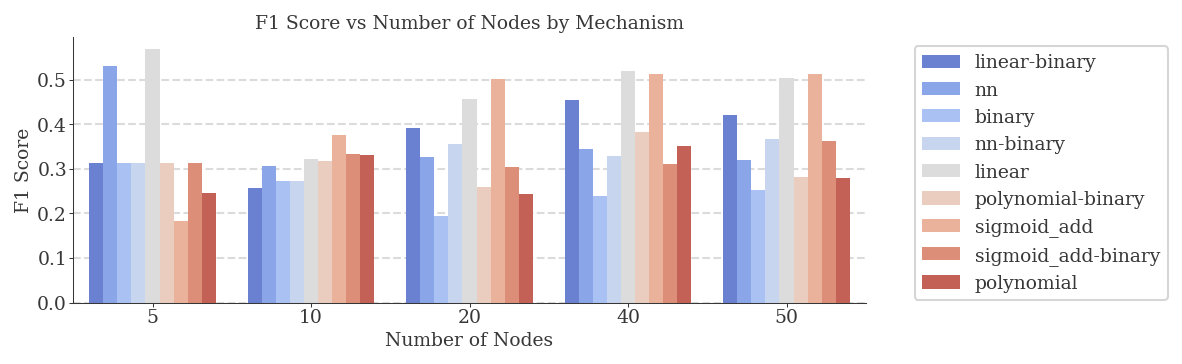

In [26]:
# Set publication theme
set_pub_theme()

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 2.5), dpi=150)

# Create bar plot with mechanism hue
sns.barplot(data=df, x='nodes', y='f1', hue='mechanism',
           palette='coolwarm', errorbar=None)
# Add grid to plot
ax.grid(True, axis='y', linestyle='--', alpha=0.7, linewidth=1)

# Customize axis
ax.set_xlabel('Number of Nodes')
ax.set_ylabel('F1 Score')
# ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_title('F1 Score vs Number of Nodes by Mechanism')

# Add legend outside plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove spines and adjust layout
sns.despine()
plt.tight_layout()
plt.show()


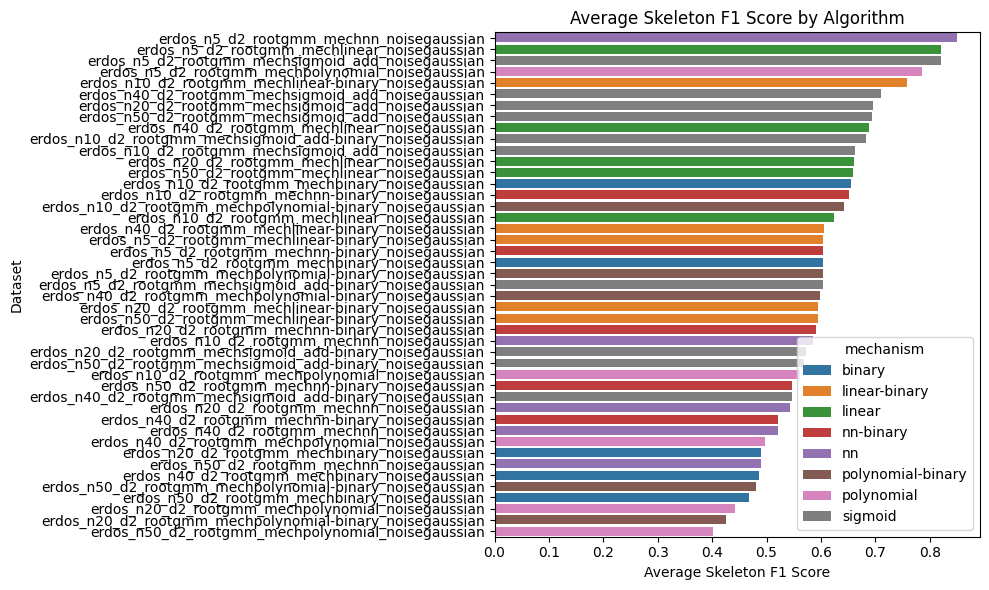

In [ ]:

# Calculate mean skeleton f1 scores by algorithm
mean_f1 = df.groupby('dataset_name')['skeleton_f1'].mean().sort_values()

# Create horizontal bar plot
plt.figure(figsize=(10, 6))
# Group by both dataset_name and mechanism, get mean f1 scores
mean_f1_by_mech = df.groupby(['dataset_name', 'mechanism'])['skeleton_f1'].mean().reset_index()

# Sort by the overall mean f1 score to order datasets
dataset_order = df.groupby('dataset_name')['skeleton_f1'].mean().sort_values(ascending=False).index

# Create horizontal bar plot with hue for mechanism, ordered by metric
sns.barplot(data=mean_f1_by_mech, y='dataset_name', x='skeleton_f1', hue='mechanism', orient='h', order=dataset_order)
plt.title('Average Skeleton F1 Score by Algorithm')
plt.xlabel('Average Skeleton F1 Score')
plt.ylabel('Dataset')
plt.tight_layout()
plt.show()

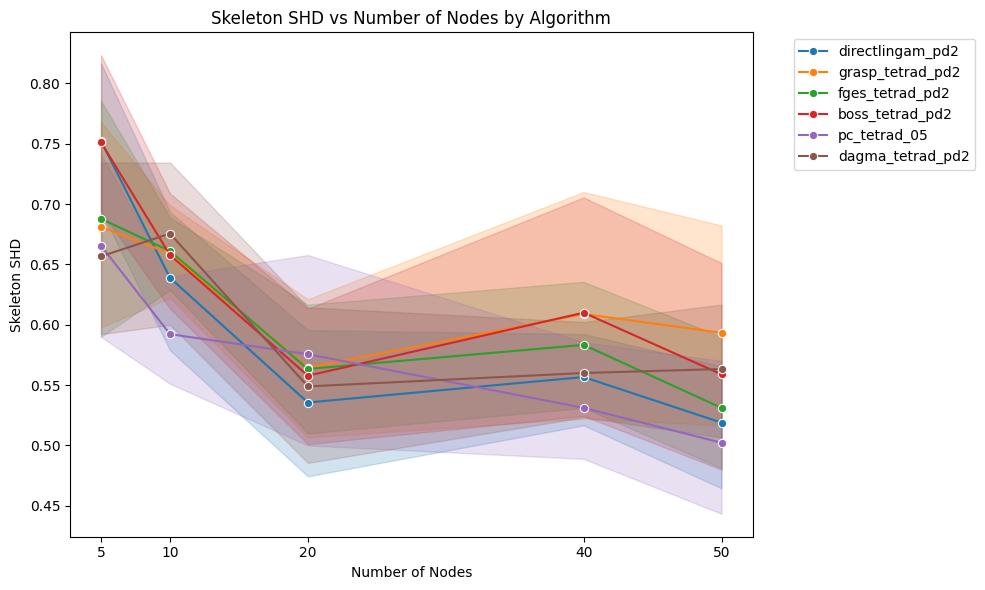

In [ ]:

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='nodes', y='skeleton_f1', hue='algorithm_name', marker='o')
plt.title('Skeleton SHD vs Number of Nodes by Algorithm')
plt.xlabel('Number of Nodes')
plt.ylabel('Skeleton SHD')
plt.xticks(df['nodes'].unique())
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
